[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/liamdev07/machine-learning-laboratory/blob/main/08_Naive_Bayes_Text/practical_08.ipynb)

# Practical 08 — Naive Bayes Classifier for Text (SMS Spam)

## 1. Aim & Objectives

**Aim:** To implement the Naive Bayes classifier for text classification and evaluate its performance.

**Objectives:**
1. Convert SMS messages into a numeric word-count matrix using `CountVectorizer`.
2. Train a `MultinomialNB` model to classify each message as ham or spam.
3. Report accuracy, plot the confusion matrix and test the model on new messages.

## 2. Complete Python Code


Shape of dataset : (5572, 2)
label
ham     4825
spam     747
Name: count, dtype: int64
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...

Number of words in the vocabulary : 7403

Accuracy : 0.9848

Classification report:
              precision    recall  f1-score   support

         ham       0.99      0.99      0.99       966
        spam       0.96      0.92      0.94       149

    accuracy                           0.98      1115
   macro avg       0.98      0.96      0.97      1115
weighted avg       0.98      0.98      0.98      1115

Prediction: spam | Congratulations! You have won a FREE ticket, claim your prize now
Prediction: ham | Hey, are we still meeting for the lab practi

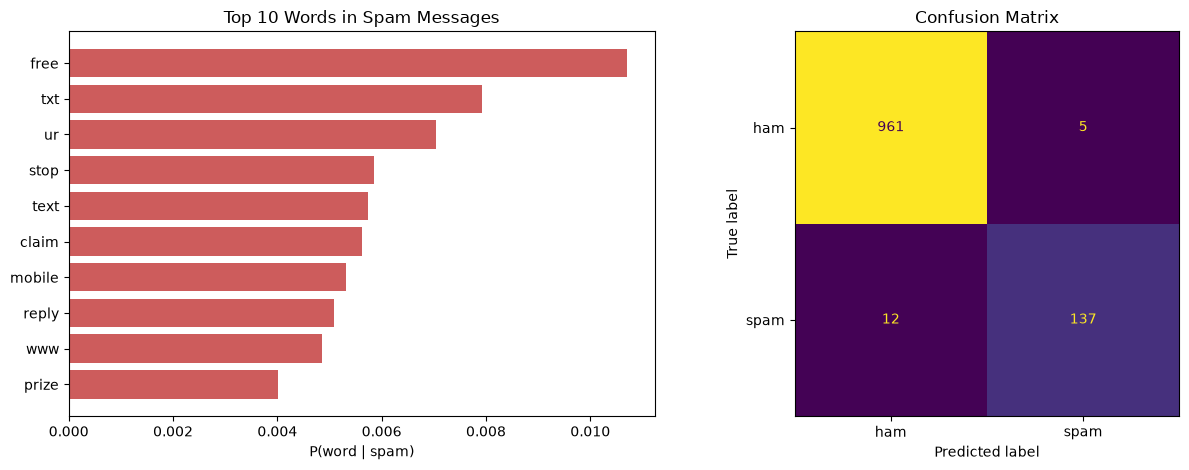

In [1]:
# Practical 08 - Naive Bayes Classifier for Text (SMS Spam)
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

# Step 1: Load the dataset
CSV = "data/sms_spam.csv"
URL = "https://raw.githubusercontent.com/liamdev07/machine-learning-laboratory/main/08_Naive_Bayes_Text/data/sms_spam.csv"
path = CSV if os.path.exists(CSV) else URL
df = pd.read_csv(path)

print("Shape of dataset :", df.shape)
print(df["label"].value_counts())
print(df.head())

# Step 2: Separate the text and the label
X = df["message"]
y = df["label"]

# Step 3: Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 4: Convert text into a word-count matrix
vectorizer = CountVectorizer(stop_words="english")
X_train_counts = vectorizer.fit_transform(X_train)
X_test_counts = vectorizer.transform(X_test)
print("\nNumber of words in the vocabulary :", len(vectorizer.get_feature_names_out()))

# Step 5: Train the Naive Bayes model
model = MultinomialNB(alpha=1.0)
model.fit(X_train_counts, y_train)
y_pred = model.predict(X_test_counts)

print("\nAccuracy :", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred))

# Step 6: Test the model on new messages
new_messages = [
    "Congratulations! You have won a FREE ticket, claim your prize now",
    "Hey, are we still meeting for the lab practical tomorrow?",
]
for text, result in zip(new_messages, model.predict(vectorizer.transform(new_messages))):
    print("Prediction:", result, "|", text)

# Step 7: Plot the top spam words and the confusion matrix
spam_index = list(model.classes_).index("spam")
log_prob = model.feature_log_prob_[spam_index]
words = vectorizer.get_feature_names_out()
top = np.argsort(log_prob)[-10:]

fig, ax = plt.subplots(1, 2, figsize=(13, 4.8))

ax[0].barh(words[top], np.exp(log_prob[top]), color="indianred")
ax[0].set_title("Top 10 Words in Spam Messages")
ax[0].set_xlabel("P(word | spam)")

ConfusionMatrixDisplay.from_estimator(model, X_test_counts, y_test, ax=ax[1], colorbar=False)
ax[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.show()


## 3. Line-by-Line Code Explanation

- `from sklearn.feature_extraction.text import CountVectorizer` — turns sentences into numbers by counting how many times each word appears.
- `from sklearn.naive_bayes import MultinomialNB` — the Naive Bayes model made for word counts.
- `df["label"].value_counts()` — shows how many ham (normal) and spam messages the dataset contains.
- `X = df["message"]` — the raw text of every SMS; `y = df["label"]` — ham or spam.
- `train_test_split(..., stratify=y)` — keeps the same ham/spam ratio in the training and testing sets.
- `CountVectorizer(stop_words="english")` — builds the vocabulary and ignores very common words such as "the", "is" and "and".
- `vectorizer.fit_transform(X_train)` — learns the vocabulary from the training messages and converts them into a count matrix (one row per message, one column per word).
- `vectorizer.transform(X_test)` — converts the test messages using the **same** vocabulary, without learning anything new.
- `MultinomialNB(alpha=1.0)` — Naive Bayes with Laplace smoothing. `alpha=1` adds 1 to every word count so that a word never seen in training does not make the probability zero.
- `model.fit(X_train_counts, y_train)` — counts how often each word appears in ham and in spam and turns those counts into probabilities.
- `model.predict(...)` — applies Bayes' theorem and picks the class with the higher probability.
- `accuracy_score` and `classification_report` — overall correctness plus precision, recall and F1 for ham and spam separately.
- `vectorizer.transform(new_messages)` — converts brand-new sentences into the same count format so the trained model can classify them.
- `model.feature_log_prob_` — the learned log probability of every word for each class; `np.exp` converts it back to a normal probability.
- `np.argsort(log_prob)[-10:]` — picks the 10 words with the highest probability in spam.
- `ax[0].barh(...)` — a horizontal bar chart of those top spam words.
- `ConfusionMatrixDisplay.from_estimator(...)` — draws the confusion matrix of the test predictions.


## 4. Output & Graph Interpretation

The bar chart shows typical spam words such as "free", "txt", "claim" and "prize", which the model relies on the most when it marks a message as spam.

The confusion matrix has very few off-diagonal values, so accuracy is around 98% — Naive Bayes works very well on text even though it assumes that all words are independent.
